In [1]:
import MEArec as mr
import numpy as np
import matplotlib.pylab as plt
import spikeinterface.extractors as se
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.comparison as sc
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
#import seaborn as sns
import spikeinterface.full as si
#%matplotlib inline
from pathlib import Path
import spikeinterface as si
from scipy.io import savemat
import numpy as np

c:\Users\ldd77\clustering_neuron_spikes_with_deep_learning\ss_env312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
recording_file_name = Path("F:\\10_600Neuron300SecondRecordingWithLevel10Noise.h5")
dir_to_save_location_to = Path("F:\\10_600Neuron300SecondRecordingWithLevel10Noise\\ground_truth")


noise_level (no parallelization): 100%|██████████| 20/20 [00:10<00:00,  1.84it/s]
Compute : spike_amplitudes + spike_locations (no parallelization): 100%|██████████| 301/301 [03:06<00:00,  1.61it/s]


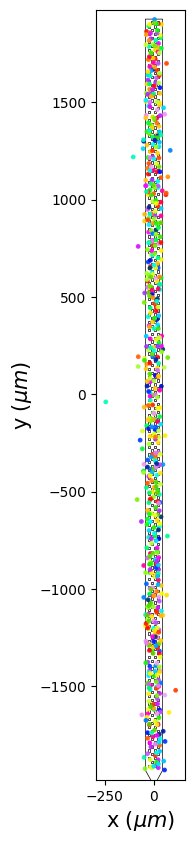

In [16]:
recording, sorting = se.read_mearec(recording_file_name);
recgen = mr.load_recordings(recording_file_name)
analyzer = si.create_sorting_analyzer(sorting=sorting,recording=recording,format="memory")
analyzer.compute(["random_spikes","waveforms","templates","noise_levels"])
analyzer.compute(["spike_amplitudes","unit_locations","spike_locations","template_metrics"])
sw.plot_unit_locations(analyzer, figsize=(10,10))

array([[  -24., -1910.],
       [  -24., -1870.],
       [  -24., -1830.],
       [  -24., -1790.],
       [  -24., -1750.],
       [  -24., -1710.],
       [  -24., -1670.],
       [  -24., -1630.],
       [  -24., -1590.],
       [  -24., -1550.],
       [  -24., -1510.],
       [  -24., -1470.],
       [  -24., -1430.],
       [  -24., -1390.],
       [  -24., -1350.],
       [  -24., -1310.],
       [  -24., -1270.],
       [  -24., -1230.],
       [  -24., -1190.],
       [  -24., -1150.],
       [  -24., -1110.],
       [  -24., -1070.],
       [  -24., -1030.],
       [  -24.,  -990.],
       [  -24.,  -950.],
       [  -24.,  -910.],
       [  -24.,  -870.],
       [  -24.,  -830.],
       [  -24.,  -790.],
       [  -24.,  -750.],
       [  -24.,  -710.],
       [  -24.,  -670.],
       [  -24.,  -630.],
       [  -24.,  -590.],
       [  -24.,  -550.],
       [  -24.,  -510.],
       [  -24.,  -470.],
       [  -24.,  -430.],
       [  -24.,  -390.],
       [  -24.,  -350.],


In [17]:
channel_locations = recording._properties["location"]

In [18]:
unit_locations = si.postprocessing.compute_unit_locations(analyzer)

In [19]:
savemat(dir_to_save_location_to / "neuron_unit_locations.mat", {"unit_locations": unit_locations})
savemat(dir_to_save_location_to / "channel_locations.mat", {"channel_locations": channel_locations})